# Linear Regression class

In [1]:
 import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df =pd.read_csv("Advertising.csv")

In [3]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


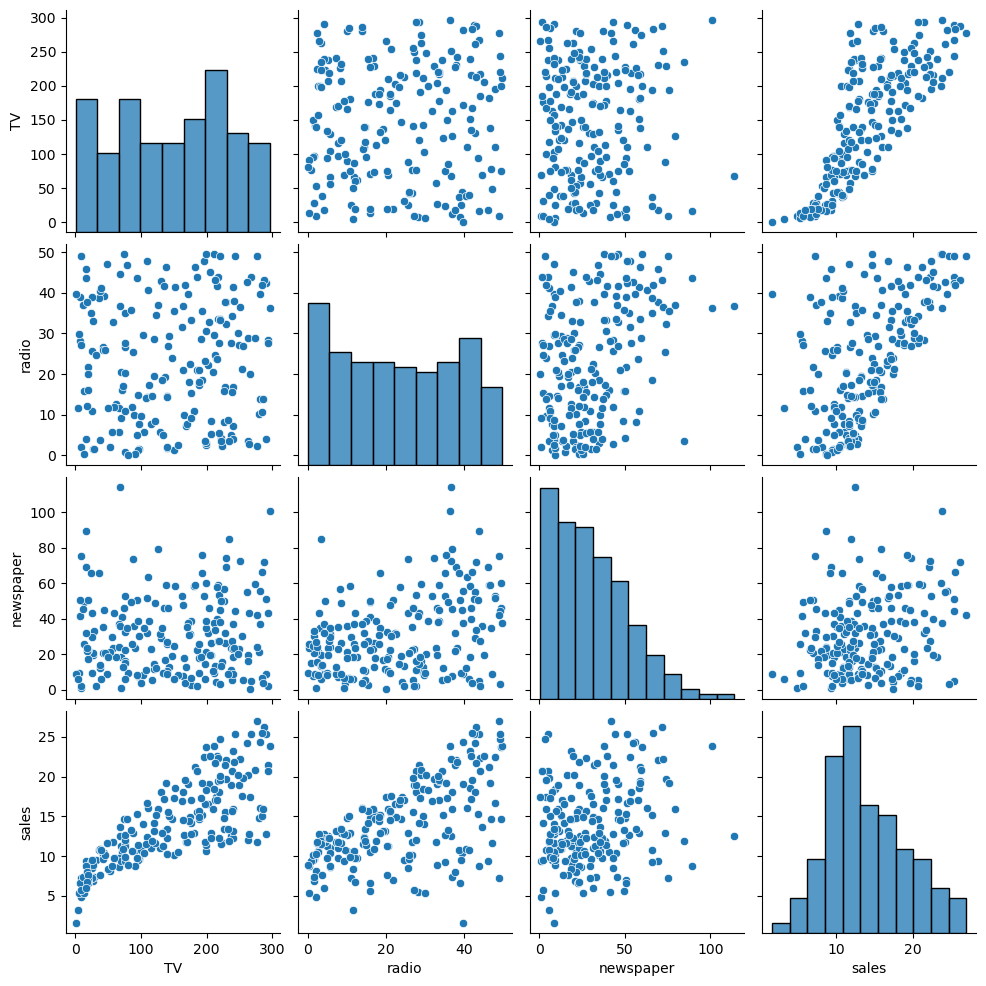

In [4]:
#the dataset is supervised cause it is labelled the output col is sales 
#in supervised learning it is of regression type cause in regression the output values are
#continuous but in classification the values are in categories 
#before applying regression algo we check whether there is linearity among the data or not
sns.pairplot(df) #using seaborn

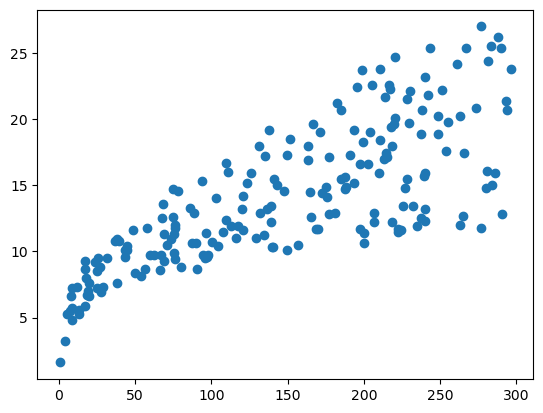

In [5]:
#to check the linearity we can see the input v/s output col e.g. TV/sales data is linear 
#we can pass a best fitted line 
#doing the same using matplotlib
plt.scatter(x =df['TV'],y=df['sales']) #tv data is approx linear with sales data

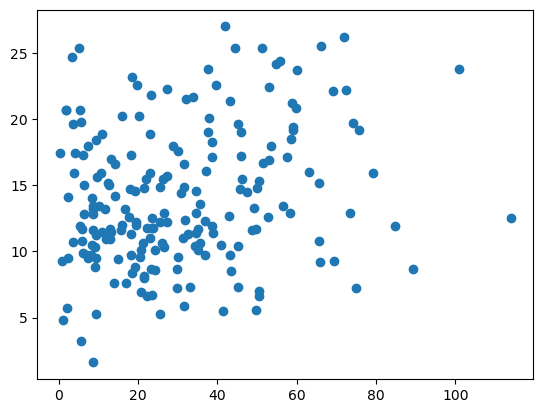

In [6]:
plt.scatter(x=df['newspaper'],y= df['sales']) #here the newspaper data is not linear 

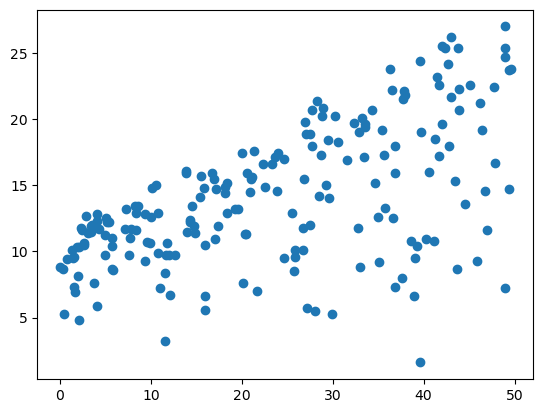

In [7]:
plt.scatter(x=df['radio'],y= df['sales']) #does have some linearity

In [8]:
#the dataset has input and output columns so we can split it 
from sklearn.model_selection import train_test_split

In [9]:
df.columns 

Index(['TV', 'radio', 'newspaper', 'sales'], dtype='object')

In [10]:
# X =df.drop('sales',axis =1)
# y =df['sales']
#here another method of doing it 
X_train,X_test,y_train,y_test = train_test_split(df.iloc[:,:-1],df.iloc[:,-1],test_size =0.2,random_state =42)

#df.iloc[:,:-1]--> :>take all rows, :-1> take all columns except the last one
#df,iloc[:,-1) --> :> take all rows, -1> last column 

In [11]:
X_train.shape, X_test.shape,y_train.shape, y_test.shape

((160, 3), (40, 3), (160,), (40,))

# applying linear regression

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
mod =LinearRegression()

In [14]:
mod.fit(X_train,y_train) #traing model with the 80% data of input output
y_pred =mod.predict(X_test) #for prediction we can't use the 20percent output data hence
#y_test won't come here 

In [15]:
y_pred #these are the predicted value inform of array as model can't be perfect hence value
#vary

array([16.4080242 , 20.88988209, 21.55384318, 10.60850256, 22.11237326,
       13.10559172, 21.05719192,  7.46101034, 13.60634581, 15.15506967,
        9.04831992,  6.65328312, 14.34554487,  8.90349333,  9.68959028,
       12.16494386,  8.73628397, 16.26507258, 10.27759582, 18.83109103,
       19.56036653, 13.25103464, 12.33620695, 21.30695132,  7.82740305,
        5.80957448, 20.75753231, 11.98138077,  9.18349576,  8.5066991 ,
       12.46646769, 10.00337695, 21.3876709 , 12.24966368, 18.26661538,
       20.13766267, 14.05514005, 20.85411186, 11.0174441 ,  4.56899622])

# metrics R2_score
metrics has many other funct too that we will see later for now we will only use r2_score
and mean absoulute error 


In [16]:
from sklearn.metrics import r2_score,mean_absolute_error
#to check the performace of our model we will find these 2 parameters
mean_absolute_error(y_test,y_pred) #here we pass the actual output(y_test) and predicted 
#output(y_pred)


1.4607567168117606

In [17]:
r2_score(y_test,y_pred) #similarly we pass the value model hasn't seen and the value it has
#predictt

0.899438024100912

# linear regression
explains relationship b/w the dependent (output) variable y and the independed (prediced)
variable X using a straight line y =b0+b1x
Random error(residual) = actual value - predicted value
main goal of linear regression is to reduce the random or residual error 
it draws a bestfit line b/w the multiple input columns and the output columns

In [18]:
#now we will build  a predictive system

# predictive system


In [23]:
df.iloc[0] #getting first row

TV           230.1
radio         37.8
newspaper     69.2
sales         22.1
Name: 0, dtype: float64

In [32]:
#now we want to predict value like we pass the column value of tv newspaper radio and the 
#model should return the output sales so we will create a funct
def predict_sales(tv_budget,radio_budget,newspaper_budget):
    features = np.array([[tv_budget,radio_budget,newspaper_budget]]) #convert the  input parameters
    #in 2d array because sklearn expects 2d array...
    results= mod.predict(features).reshape(1,-1) #-1 because we only want the value of sales col
    #1 refers to 1st row value reshape(rows,columns)
    return results[0] #return result of index 0 

In [33]:
#passing the values
tv_budget =230.1
radio_budget =37.8
newspaper_budget =69.2
sales = predict_sales(tv_budget,radio_budget,newspaper_budget)

C:\Users\uvtec\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [34]:
sales #here we get the predicted sales value in form of array

array([20.61397147])

# converting the model into file and making dashboard using streamlit

In [36]:
import pickle #this library is used to save your model
pickle.dump(mod,open('linear_regression_model.pkl','wb')) #wb--> write+binary mode
#means createe a binary file and save the model into it
#it will create a file and write all the data into it, python saves these as binary data